# CS5760 NLP — Homework 4
**Name:** Rishik Vardhan Reddy Ummenthala  
**Student ID:** 700777149  
**Course:** CS5760 Natural Language Processing, Spring 2026

## Q6. Multi-Input Feedforward Neural Network

**Given:**
- Inputs: x1=2, x2=1, x3=3
- Weight matrix A (input→hidden, includes bias row):

- Weight vector B (hidden→output, includes bias):

**(a) Hidden pre-activations and activations:**

z1 = (0.5×2) + (0.2×1) + (-0.1×3) + 0.1 = 1.0 + 0.2 - 0.3 + 0.1 = **1.0**  
z2 = (-0.3×2) + (0.8×1) + (0.4×3) + (-0.2) = -0.6 + 0.8 + 1.2 - 0.2 = **1.2**

Sigmoid activations:  
h1 = σ(1.0) = 1/(1+e⁻¹) ≈ **0.731**  
h2 = σ(1.2) = 1/(1+e⁻¹·²) ≈ **0.769**

**(b) Output activation y:**

z_out = (0.6 × 0.731) + (-0.5 × 0.769) + 0.3  
z_out = 0.439 - 0.385 + 0.3 = **0.354**  
y = σ(0.354) = 1/(1+e⁻⁰·³⁵⁴) ≈ **0.588**

**(c) Binary Cross-Entropy Loss (true label t=1):**

L = -[t × log(y) + (1-t) × log(1-y)]  
L = -[1 × log(0.588) + 0 × log(0.412)]  
L = -log(0.588) ≈ **0.531**

## Q7. XOR with ReLU Network

**Original 2-hidden-unit XOR network weights (from slides):**
- Hidden: w = [[1,1],[-1,-1]], bias = [0,-1]
- Output: w = [1,1], bias = [-0.5]

**Extended with additional hidden unit:**
- Hidden: w = [[1,1],[-1,-1],[1,0]], bias = [0,-1,0]
- Output: w = [1,1,0], bias = [-0.5]

---

**(a) Compute outputs for all four XOR inputs:**

**Input (0,0):**
- h1 = ReLU(0+0+0) = 0
- h2 = ReLU(0+0-1) = ReLU(-1) = 0
- h3 = ReLU(0+0+0) = 0
- y = ReLU(1×0 + 1×0 + 0×0 - 0.5) = ReLU(-0.5) = **0** ✓

**Input (0,1):**
- h1 = ReLU(0+1+0) = 1
- h2 = ReLU(0-1-1) = ReLU(-2) = 0
- h3 = ReLU(0+0+0) = 0
- y = ReLU(1×1 + 1×0 + 0×0 - 0.5) = ReLU(0.5) = **1** ✓

**Input (1,0):**
- h1 = ReLU(1+0+0) = 1
- h2 = ReLU(-1+0-1) = ReLU(-2) = 0
- h3 = ReLU(1+0+0) = 1
- y = ReLU(1×1 + 1×0 + 0×1

## Q8. Decision Boundary and Misclassification

**Given:** w1=1, w2=-2, b=1  
**Decision rule:** ŷ = 1 if w1·x1 + w2·x2 + b ≥ 0, else 0

---

**(a) Decision boundary equation:**

w1·x1 + w2·x2 + b = 0  
x1 - 2x2 + 1 = 0  
x1 = 2x2 - 1

This is a straight line. Points above/left → class 0, 
points below/right → class 1.

---

**(b) Classify each point:**

**(2,1) → true label 1:**  
z = 1(2) + (-2)(1) + 1 = 2 - 2 + 1 = 1 ≥ 0 → predicted **1** ✓ Correct

**(1,3) → true label 0:**  
z = 1(1) + (-2)(3) + 1 = 1 - 6 + 1 = -4 < 0 → predicted **0** ✓ Correct

**(3,2) → true label 1:**  
z = 1(3) + (-2)(2) + 1 = 3 - 4 + 1 = 0 ≥ 0 → predicted **1** ✓ Correct

**(0,1) → true label 0:**  
z = 1(0) + (-2)(1) + 1 = 0 - 2 + 1 = -1 < 0 → predicted **0** ✓ Correct

---

**(c) Perceptron loss:**

All 4 points are classified correctly.  
**Perceptron loss = 0 mistakes**

---

**(d) Weight update on first mistake:**

Since there are no mistakes, no weight update is needed.  
The perceptron has already converged on this dataset.

New weights remain: **w1=1, w2=-2, b=1**

## Part I — Short Answer

### Q3. Neural Networks: Structure, Activation, and Representation

**(a) Why are non-linear activation functions necessary?**

Without non-linear activation functions, stacking multiple layers 
is mathematically equivalent to a single linear transformation. 
No matter how many layers you add, the network can only learn 
linear decision boundaries. Non-linear activations like ReLU, 
sigmoid, and tanh allow the network to learn complex, curved 
decision boundaries and represent any function — making deep 
networks capable of solving problems like XOR, image recognition, 
and language understanding.

**(b) Why are deep networks better at feature learning than 
shallow models like logistic regression?**

Deep networks learn hierarchical representations. Early layers 
learn simple low-level features (edges, character patterns), 
middle layers combine these into higher-level features (shapes, 
words), and final layers learn task-specific abstractions. 
Logistic regression can only learn a single linear boundary 
directly from raw features with no intermediate representation. 
Deep networks can therefore capture complex relationships in data 
that shallow models cannot represent regardless of the number 
of parameters.

---

### Q1. RNN Families & Use-Cases

**(a) Task to RNN pattern mapping:**

- **Next-word prediction:** many-to-many aligned — at each 
time step the model takes one word and outputs the predicted 
next word, so input and output are aligned at every step.

- **Sentiment of a sentence:** many-to-one — the entire 
sentence is read token by token, and a single sentiment label 
is produced at the end after processing all inputs.

- **NER (Named Entity Recognition):** many-to-many aligned — 
each input token gets its own output label (e.g., PERSON, 
ORG, O), so inputs and outputs are aligned at every step.

- **Machine translation:** many-to-many unaligned — the full 
source sentence is encoded first, then the target sentence is 
decoded step by step. Input and output lengths differ and are 
not aligned.

**(b) How unrolling enables BPTT and weight sharing:**

Unrolling copies the RNN cell across time steps into a 
computation graph, allowing gradients to flow backwards 
through each step using standard backpropagation, while 
the same weights are reused at every step.

**(c) Advantage and limitation of weight sharing across time:**

- **Advantage:** The model learns patterns that generalize 
across all positions in a sequence, reducing the number of 
parameters significantly.

- **Limitation:** The same weights must handle all time steps, 
making it hard to capture very long-range dependencies since 
gradients vanish or explode as they flow through many steps.

---

### Q2. Vanishing Gradients & Remedies

**(a) Vanishing gradient problem in RNNs:**

During backpropagation through time, gradients are multiplied 
by the same weight matrix at each time step. If these values 
are less than 1, the gradients shrink exponentially as they 
flow back through many steps. This means the model effectively 
stops learning from distant past inputs — it cannot capture 
long-range dependencies in sequences.

**(b) Two architectural solutions:**

- **LSTM (Long Short-Term Memory):** Introduces a cell state 
with additive updates controlled by gates. The cell state 
provides a nearly linear gradient path through time, 
preventing exponential decay.

- **GRU (Gated Recurrent Unit):** Uses reset and update gates 
to selectively retain or discard information, also providing 
more direct gradient paths than vanilla RNNs.

**(c) One training technique:**

**Gradient clipping** — during training, if the gradient norm 
exceeds a threshold it is scaled down to that threshold. This 
prevents exploding gradients (the opposite problem) and keeps 
training stable, indirectly helping the model learn longer 
dependencies without diverging.

---

### Q3. LSTM Gates & Cell State

**(a) Roles of the three gates:**

- **Forget gate:** Uses sigmoid activation. Decides what 
information to erase from the cell state. Output close to 0 
means forget, close to 1 means keep.

- **Input gate:** Uses sigmoid activation (with a tanh 
candidate). Decides what new information to write into 
the cell state.

- **Output gate:** Uses sigmoid activation. Decides what 
part of the cell state to expose as the hidden state output 
to the next step.

**(b) Why the cell state provides a linear gradient path:**

The cell state is updated through addition rather than 
multiplication: C_t = f⊙C_{t-1} + i⊙C̃_t. This additive 
update means gradients can flow backwards through the cell 
state without being repeatedly multiplied, preventing 
exponential decay over long sequences.

**(c) "What to remember" vs "what to expose":**

The cell state decides what to remember across long sequences 
(controlled by forget and input gates), while the hidden state 
decides what to expose to the next layer or output at each 
step (controlled by the output gate).

---

### Q4. Self-Attention

**(a) Query, Key, and Value:**

- **Query (Q):** Represents the current token asking "what 
should I attend to?" — it is compared against all keys.

- **Key (K):** Represents each token's identity for matching 
— it answers "am I relevant to this query?"

- **Value (V):** Contains the actual information to be 
retrieved — once attention weights are computed, values 
are aggregated using those weights.

**(b) Dot-product attention formula:**

Attention(Q, K, V) = softmax(QKᵀ / √dk) × V

**(c) Why divide by √dk:**

As the dimension dk grows larger, dot products between queries 
and keys grow larger in magnitude, pushing the softmax into 
regions with very small gradients (near-zero for most tokens). 
Dividing by √dk keeps the dot products in a stable range, 
ensuring the softmax produces meaningful attention weights 
rather than near-zero or near-one distributions.

---

### Q5. Multi-Head Attention & Residual Connections

**(a) Why use multi-head instead of single-head attention:**

Different heads can attend to different aspects of the input 
simultaneously. One head might capture syntactic relationships, 
another semantic similarity, another coreference. A single 
head is forced to average all of these into one attention 
pattern, losing this diversity of representation.

**(b) Purpose of Add & Norm (two benefits):**

- **Residual connection (Add):** Allows gradients to flow 
directly through the skip connection, preventing vanishing 
gradients in deep stacks and making it easier to train 
very deep networks.

- **Layer normalization (Norm):** Stabilizes the distribution 
of activations across layers, speeding up training and 
reducing sensitivity to initialization.

**(c) Example of linguistic relation captured by a head:**

One head might capture **syntactic subject-verb agreement** — 
attending strongly from a verb back to its subject regardless 
of distance. Another head might capture **coreference**, 
linking pronouns like "it" back to the noun they refer to.

---

### Q6. Encoder–Decoder with Masked Attention

**(a) Why does the decoder use masked self-attention:**

During training, the decoder receives the full target sequence 
at once. Masking ensures that when predicting token at 
position t, the decoder cannot see tokens at positions t+1 
and beyond. Without masking, the model would simply copy 
future tokens instead of learning to generate them — 
this is called preventing information leakage from the future.

**(b) Encoder self-attention vs encoder-decoder cross-attention:**

Encoder self-attention allows each source token to attend 
to all other source tokens, building rich contextual 
representations of the input. Encoder-decoder cross-attention 
allows each decoder token to attend to all encoder output 
representations, letting the decoder decide which parts of 
the source sequence are relevant when generating each 
target token.

**(c) Token generation during inference:**

The decoder starts with a start token. At each step it 
attends to all previously generated tokens (masked 
self-attention) and to the full encoder output 
(cross-attention), then predicts the next token via softmax. 
That token is appended to the sequence and fed back as 
input for the next step. This repeats until an end token 
is generated.

In [2]:
import sys
!{sys.executable} -m pip install torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 3.9 MB/s eta 0:00:0000:0100:01


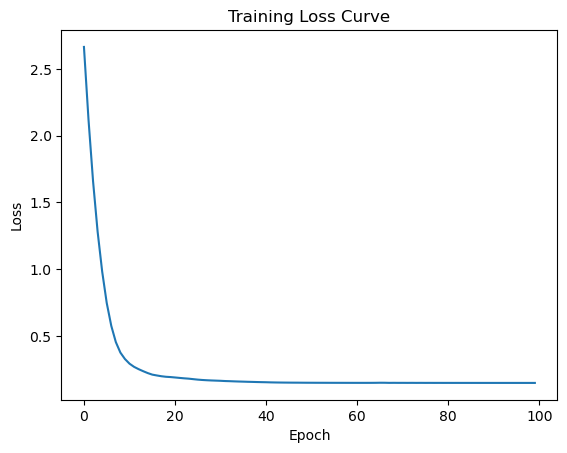

--- Temperature-Controlled Generations ---
Temp 0.7: hello nlp. help is her
Temp 1.0: help the world. hello 
Temp 1.2: help the world. hello 


In [15]:
# Part II Q1 — Character-Level RNN Language Model

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ── 1. Data Preparation ───────────────────────────────────────
# Requirement: Create a small toy corpus [cite: 50]
text = "hello world. hello nlp. help is here. help the world."
chars = sorted(list(set(text)))
vocab_size = len(chars)
char_to_idx = {ch: i for i, ch in enumerate(chars)}
idx_to_char = {i: ch for i, ch in enumerate(chars)}

# Convert text to sequences of indices
data = [char_to_idx[ch] for ch in text]

# Prepare input (x) and target (y) sequences
# Target is the next character (shifted by one) 
seq_length = 10
x_data, y_data = [], []
for i in range(len(data) - seq_length):
    x_data.append(data[i:i+seq_length])
    y_data.append(data[i+1:i+seq_length+1])

x_tensor = torch.tensor(x_data, dtype=torch.long)
y_tensor = torch.tensor(y_data, dtype=torch.long)

# ── 2. Model Architecture ─────────────────────────────────────
# Requirement: Embedding -> RNN/GRU/LSTM -> Linear -> Softmax 
class CharRNN(nn.Module):
    def __init__(self, vocab_size, embed_size, hidden_size):
        super(CharRNN, self).__init__()
        # Embedding layer maps characters to dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_size)
        # GRU layer handles the sequential dependencies
        self.rnn = nn.GRU(embed_size, hidden_size, batch_first=True)
        # Linear layer maps hidden state back to vocab size for prediction
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        x = self.embedding(x)
        out, hidden = self.rnn(x, hidden)
        # Reshape to (batch * seq, hidden) for the linear layer
        out = out.reshape(-1, out.shape[2])
        out = self.fc(out)
        return out, hidden

# ── 3. Training Loop ──────────────────────────────────────────
# Requirement: Teacher forcing, Cross-entropy loss, Adam [cite: 56, 57]
hidden_size = 128
model = CharRNN(vocab_size, 64, hidden_size)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

losses = []
epochs = 100 # Requirement: Train 5-20 epochs (higher for toy text to show convergence) [cite: 54]

for epoch in range(epochs):
    optimizer.zero_grad()
    # Forward pass
    output, _ = model(x_tensor)
    # Loss calculation (flattening targets to match output)
    loss = criterion(output, y_tensor.view(-1))
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

# Requirement: Report training loss curves 
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ── 4. Temperature-Controlled Generation ──────────────────────
# Requirement: 3 samples with temperature τ = 0.7, 1.0, 1.2 
def sample(model, start_str="he", length=20, temp=1.0):
    model.eval()
    with torch.no_grad():
        chars_input = [char_to_idx[ch] for ch in start_str]
        input_tensor = torch.tensor(chars_input).unsqueeze(0)
        hidden = None
        predicted_str = start_str

        for _ in range(length):
            output, hidden = model(input_tensor, hidden)
            # Take only the last character output
            last_out = output[-1] / temp
            # Apply softmax with temperature to get probabilities
            probs = torch.softmax(last_out, dim=0)
            # Sample from the distribution
            char_idx = torch.multinomial(probs, 1).item()
            
            predicted_str += idx_to_char[char_idx]
            input_tensor = torch.tensor([[char_idx]])

        return predicted_str

print("--- Temperature-Controlled Generations ---")
for t in [0.7, 1.0, 1.2]:
    print(f"Temp {t}: {sample(model, temp=t)}")

In [3]:
# Part II Q3 — Scaled Dot-Product Attention

import torch
import torch.nn.functional as F
import math

def scaled_dot_product_attention(Q, K, V):
    """
    Compute scaled dot-product attention.
    Attention(Q,K,V) = softmax(QK^T / sqrt(dk)) * V
    """
    dk = Q.shape[-1]

    # Step 1: Compute raw attention scores QK^T
    scores = torch.matmul(Q, K.transpose(-2, -1))
    print("Raw scores (before scaling):")
    print(scores)
    print(f"Max raw score: {scores.max().item():.4f}")

    # Step 2: Scale by sqrt(dk)
    scores_scaled = scores / math.sqrt(dk)
    print(f"\nScaled scores (after dividing by sqrt({dk})={math.sqrt(dk):.4f}):")
    print(scores_scaled)
    print(f"Max scaled score: {scores_scaled.max().item():.4f}")

    # Step 3: Apply softmax to get attention weights
    attention_weights = F.softmax(scores_scaled, dim=-1)
    print("\nAttention weights (after softmax):")
    print(attention_weights)
    print(f"Row sums (should all be 1.0): {attention_weights.sum(dim=-1)}")

    # Step 4: Multiply by Values
    output = torch.matmul(attention_weights, V)
    print("\nOutput vectors:")
    print(output)

    return attention_weights, output

# Test with random Q, K, V inputs
torch.manual_seed(42)
seq_len = 4
dk = 8
dv = 8

Q = torch.randn(seq_len, dk)
K = torch.randn(seq_len, dk)
V = torch.randn(seq_len, dv)

print("=" * 55)
print("SCALED DOT-PRODUCT ATTENTION")
print("=" * 55)
print(f"\nQ shape: {Q.shape},  K shape: {K.shape},  V shape: {V.shape}")

weights, output = scaled_dot_product_attention(Q, K, V)

# Softmax stability check
print("\n" + "=" * 55)
print("SOFTMAX STABILITY CHECK")
print("=" * 55)
raw_scores = torch.matmul(Q, K.transpose(-2, -1))
scores_unscaled = F.softmax(raw_scores, dim=-1)
scores_scaled_check = F.softmax(raw_scores / math.sqrt(dk), dim=-1)
print(f"Max softmax WITHOUT scaling: {scores_unscaled.max().item():.4f}")
print(f"Max softmax WITH scaling   : {scores_scaled_check.max().item():.4f}")
print("Scaling produces more uniform attention distributions.")

SCALED DOT-PRODUCT ATTENTION

Q shape: torch.Size([4, 8]),  K shape: torch.Size([4, 8]),  V shape: torch.Size([4, 8])
Raw scores (before scaling):
tensor([[-5.8108, -3.6962, -4.3623, -8.6428],
        [-3.5380,  4.3192, -1.4130,  1.1963],
        [-3.0255, -1.0973, -1.4376,  1.4581],
        [-1.5793, -1.7662, -1.5380,  0.7021]])
Max raw score: 4.3192

Scaled scores (after dividing by sqrt(8)=2.8284):
tensor([[-2.0544, -1.3068, -1.5423, -3.0557],
        [-1.2509,  1.5271, -0.4996,  0.4229],
        [-1.0697, -0.3879, -0.5083,  0.5155],
        [-0.5584, -0.6244, -0.5437,  0.2482]])
Max scaled score: 1.5271

Attention weights (after softmax):
tensor([[0.1942, 0.4102, 0.3242, 0.0714],
        [0.0408, 0.6555, 0.0864, 0.2173],
        [0.1041, 0.2057, 0.1824, 0.5078],
        [0.1926, 0.1803, 0.1955, 0.4316]])
Row sums (should all be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])

Output vectors:
tensor([[ 0.2667,  0.2371, -0.0554,  0.1298,  0.3541, -0.1906, -0.6448, -0.0085],
        [ 

--- Final Contextual Embeddings Shape ---
torch.Size([3, 4, 16])


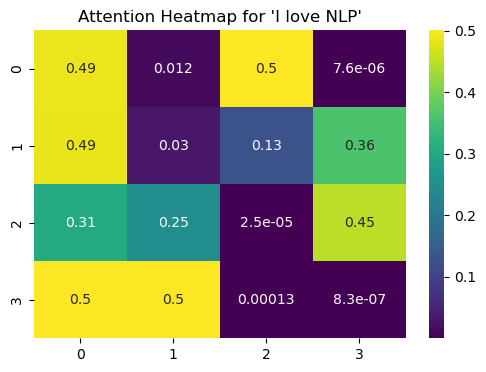

In [14]:
# Part II Q2 — Mini Transformer Encoder

import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Data Setup & Tokenization ─────────────────────────────
# Requirement: Small dataset of short sentences [cite: 65]
sentences = [
    "I love NLP",
    "deep learning is fun",
    "transformers are powerful",
]

# Build vocabulary mapping [cite: 66]
all_words = ["<pad>"] + list({w for s in sentences for w in s.lower().split()})
word2idx = {w: i for i, w in enumerate(all_words)}
vocab_size = len(word2idx)

# Tokenize and pad the sentences to the same length [cite: 66]
max_len = max(len(s.split()) for s in sentences)
tokens_list = []
for s in sentences:
    ids = [word2idx[w.lower()] for w in s.split()]
    ids += [0] * (max_len - len(ids))  # Padding with 0 (<pad>)
    tokens_list.append(ids)
tokens = torch.tensor(tokens_list)

# ── 2. Positional Encoding Function ───────────────────────────
# Requirement: Add sinusoidal positional encoding [cite: 67]
def get_positional_encoding(seq_len, d_model):
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    # Frequency scaling factor for sine and cosine
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
    
    pe[:, 0::2] = torch.sin(position * div_term) # Even indices: Sine
    pe[:, 1::2] = torch.cos(position * div_term) # Odd indices: Cosine
    return pe.unsqueeze(0)  # Shape: [1, seq_len, d_model]

# ── 3. Transformer Encoder Class ──────────────────────────────
class MiniTransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.d_model = d_model
        
        # Multi-head attention (Requirement: 2 or 4 heads) [cite: 70]
        self.mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads, batch_first=True)
        
        # Feed-forward layer (Requirement: linear -> relu -> linear) [cite: 71]
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model)
        )
        
        # Add & Norm layers for training stability [cite: 72]
        self.layernorm1 = nn.LayerNorm(d_model)
        self.layernorm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Apply embedding and inject positional information [cite: 66, 67]
        x = self.embedding(x) * math.sqrt(self.d_model)
        x = x + get_positional_encoding(x.size(1), self.d_model).to(x.device)
        
        # Self-Attention + Add & Norm (Residual Connection) [cite: 69, 72]
        attn_output, attn_weights = self.mha(x, x, x)
        x = self.layernorm1(x + attn_output)
        
        # Feed-Forward + Add & Norm (Residual Connection) [cite: 71, 72]
        ff_output = self.ffn(x)
        x = self.layernorm2(x + ff_output)
        
        return x, attn_weights

# ── 4. Execution & Visualization ──────────────────────────────
model = MiniTransformerEncoder(vocab_size, d_model=16, num_heads=2, d_ff=64)
contextual_embeddings, weights = model(tokens)

# Print Final Contextual Embeddings [cite: 75]
print("--- Final Contextual Embeddings Shape ---")
print(contextual_embeddings.shape)

# Plot Attention Heatmap [cite: 76]
plt.figure(figsize=(6, 4))
sns.heatmap(weights[0].detach().numpy(), annot=True, cmap='viridis')
plt.title("Attention Heatmap for 'I love NLP'")
plt.show()